# 2a Escola de IA e Computação do CBPF (17-21/Ago/2026)

Curso de Astrofísica Computacional

Aula 2: Medidas de redshifts fotométricos de galáxias com aprendizado de máquina 

2.b) Medida de redshifts com florestas aleatórias

## Sumário

0. Introdução (descrição de ML, Decision Trees e Random Forest) (&#x2705; beta, v1)
1. Preparação de amostras de treino e teste (beta, v1)
2. ...

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

## Introdução

Os métodos de aprendizado de máquina que vamos empregar utilizam um subconjunto dos dados disponíveis para _treinar_ um algoritmo e outros subconjunto para _testar_ o resultado do treino e verificar a pe rformance do método em dados que não foram utilizados para o treinamento.

Esta linguagem é genérica e se aplica a todos os algoritmos, o que é prático para discutir os passos de uma dada análise. Por outro lado, ela obscurece o que está ocorrendo de fato no período de treinamento. Cada método possui seu próprio algoritmo, e estes possuem—na maior parte dos casos!—bases matemáticas robustas, calcadas na estatística e na teoria de otimização.

De forma muito resumida, **redes neurais** implementam numericamente um enorme "$f\odot g\odot h$" multidimensional, e o que chamamos de "treinamento" é o processo de tirar derivadas numéricas desta grande função multidimensional e não-linear buscando minimizar uma _função de perda_ (_loss function_), que no caso mais simples se trata de um $\chi^2$.

Já as **árvores de decisão** escolhem blablabalbalb.

**Florestas aleatórias** são um _ensemble method_ que treina múltiplas árvores de decisão, cada uma com blablablalal, e escolhe blablabla tal que blabalbala.

Neste notebook, vamos criar conjuntos de treino e teste (seção 1), aplicar cada um dos algoritmos acima aos nossos dados (seção 2) e avaliar sua performance (seção 3).

**FIXME:** Completar o texto desta célula.

## Exercício 1: Redshifts fotométricos com florestas aleatórias e magnitudes

_TODO: Descrição curta do Exercício_

### 1.a) Leia, inspecione (rapidamente) os dados e crie dataframes separados com magnitudes ("features") e redshifts espectroscópicos ("target")

In [ ]:
# Load the first CSV file (assumes it contains the test data)
data = pd.read_parquet("../../data/des_dr2/des_dr2_pz_training_set_clean_vvds_vipers_gama.pq")

# The 'z' columns is the target and the 'mag_*' and 'mag_err_' columns are the predictor
redshifts = data['z']
mags = data[['mag_auto_g_dered',
             'mag_auto_r_dered',
             'mag_auto_i_dered',
             'mag_auto_z_dered',
             'mag_auto_y_dered']]

data.info()

### 1.b) Crie conjuntos de treino e teste, inicialize uma Floresta Aleatória e treine e avalie o modelo

In [10]:
# Split the data into training and test sets (e.g., 70/30 split)
Mags_train, Mags_test, z_spec_train, z_spec_test = train_test_split(mags, redshifts, test_size=0.3, random_state=42)

# Initialize the Random Forest Regressor with hyperparameters
rf = RandomForestRegressor(n_estimators=50,
                           max_depth=30,
                           max_features=None)

# Train and evaluate the Random Forest model
rf.fit(Mags_train, z_spec_train)
z_phot_mags = rf.predict(Mags_test)
print(f"Random Forest Validation MAE: {mean_absolute_error(z_spec_test, z_phot_mags)}")

Random Forest Validation MAE: 0.05670488443362095


### 1.c) Faça um gráfico de $z_{\rm spec}$ vs $z_{\rm phot}$ para avaliar visualmente a performance do algoritmo

_TODO: Descrição das etapas do exercício (calcular outliers, usar hexbin, etc)_

In [11]:
def create_ax_results(z_spec,
                      z_phot,
                      ax=None,
                      outlier_thresh=0.15,
                      figsize=(5, 4.2),
                      title="",
                      gridsize=40,
                      cmap="inferno",
                      zlim=(0, 2),
                      vmax=None,
                      mincnt=1):

    # Transform to numpy arrays
    z_spec = np.asarray(z_spec, dtype=float)
    z_phot = np.asarray(z_phot, dtype=float)

    # Separate outliers from inliers
    outlier_mask = ( np.abs(z_phot - z_spec) / (1 + z_spec) ) > outlier_thresh

    # Draw into the ax we were given (one panel of a bigger figure), or make
    # our own single-panel figure; figsize only applies in the second case
    own_figure = ax is None
    if own_figure:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # Create hexbin plot for inliers
    z_spec_inliers = z_spec[~outlier_mask]
    z_phot_inliers = z_phot[~outlier_mask]

    hexes = None
    if (~outlier_mask).any():
        hexes = ax.hexbin(z_spec_inliers, z_phot_inliers,
                          gridsize=gridsize,
                          cmap=cmap,
                          linewidths=0,
                          mincnt=mincnt,
                          norm=LogNorm(vmin=mincnt, vmax=vmax),
                          extent=(zlim[0], zlim[1], zlim[0], zlim[1]))

    # Create scatter plot for outliers
    z_spec_outliers = z_spec[outlier_mask]
    z_phot_outliers = z_phot[outlier_mask]

    if outlier_mask.any():
        ax.scatter(z_spec_outliers, z_phot_outliers,
                   s=8,
                   c="red",
                   edgecolor='white',
                   linewidth=0.4,
                   zorder=3,
                   label='Outliers (%.2f%%)' % (outlier_mask.sum() / len(outlier_mask) * 100))
        ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

    # Identity and outlier boundaries in neutral gray
    x = np.linspace(zlim[0], zlim[1], 200)
    ax.plot(x, x, color='0.25', linewidth=1.2, zorder=2)
    ax.plot(x, x + outlier_thresh * (1 + x), linestyle='--', color='0.45', linewidth=1, zorder=2)
    ax.plot(x, x - outlier_thresh * (1 + x), linestyle='--', color='0.45', linewidth=1, zorder=2)

    # Extra formatting
    if own_figure and hexes is not None:
        # In a multi-panel grid the caller adds one shared colorbar instead,
        # so that the same darkness means the same count in every panel
        fig.colorbar(hexes, ax=ax, label='Galaxies per cell')

    ax.set_xlabel('True Redshift')
    ax.set_ylabel('Predicted Redshift')
    ax.set_title(title)
    ax.set_xlim(zlim)
    ax.set_ylim(zlim)
    ax.set_aspect('equal')
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)  # otherwise the grid is drawn on top of the hexagons

    return fig, ax, hexes


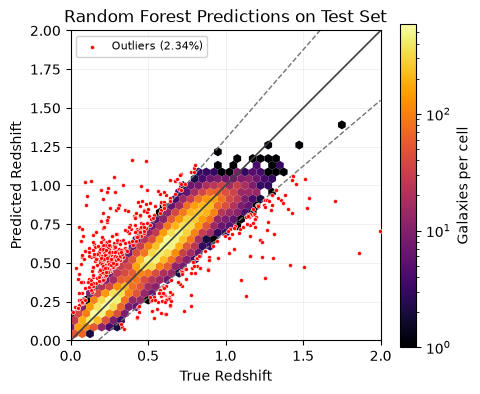

In [17]:
_ = create_ax_results(z_spec_test, z_phot_mags, title="Random Forest Predictions on Test Set", cmap='inferno')

## Exercício 2: Métricas de qualidade para redshifts fotométricos

In [ ]:
def calculate_metrics(z_spec, z_phot):
    # Calculate the metrics
    metrics = {}
    metrics['mae'] = mean_absolute_error(z_spec, z_phot)
    metrics['rmse'] = np.sqrt(mean_squared_error(z_spec, z_phot))

    metrics['std'] = np.std((z_phot - z_spec)/(1 + z_spec), ddof=1)
    metrics['nmad'] = 1.4826 * np.median(np.abs((z_phot - z_spec)/(1 + z_spec)))
    metrics['eta'] = np.sum(np.abs((z_phot - z_spec)/(1 + z_spec)) > 0.15) / len(z_spec) # Catastrophic outlier fraction
    metrics['bias'] = np.mean((z_phot - z_spec)/(1 + z_spec))
    metrics['sigbias'] = metrics['std']/np.sqrt(0.64 * len(z_spec)) # Standard error of the bias

    print('Standard Deviation: %6.4f' % metrics['std'])
    print('Normalized MAD: %6.4f' % metrics['nmad'])
    print('Catastrophic Outlier Fraction: %6.4f' % (100 * metrics['eta']))
    print('Median offset: %6.3f +/- %6.3f' % (metrics['bias'], metrics['sigbias']))

    return metrics

In [22]:
def plot_metrics(zspec,
                 zphot,
                 maximum,
                 path_to_save='',
                 title=None,
                 initial=0):
    
    '''
    Function to plot Bias, Sigma_68, Out2σ, Out3σ given a spectroscopic and photometric redshift. 
    
    Args:
    
    zspec: Numpy array with the spectroscopic redshift.
    
    zphot: Numpy array with the photometric redshifts calculated. Same size as zspec.
    
    maximum: Float that indicates the redshift max of the plots.
    
    Kwargs:
    
    initial: Float that indicates the redshift min of the plots.
    
    
    
    '''
    bins = np.arange(0, 1.3, 0.1)
    points = bins + 0.05
    fraction_outliers = []
    sigma68z = []
    sigmaz = []
    meanz = []
    outliers_2 = []
    drop_bins = []

    for index in range(len(bins) - 1):
        bin_lower = bins[index]
        bin_upper = bins[index + 1]

        binmask = (zphot >= bin_lower) & (zphot <= bin_upper)

        if not np.any(binmask):
            drop_bins.append(index)
            continue
        
        values_r = zphot[binmask]
        values_s = zspec[binmask]

        deltabias = (values_r - values_s)
        mean_bias = np.mean(deltabias)  # Mean bias for each bin
        meanz.append(mean_bias)
        
        # FIXME: This part of the code is really bad. That's not how you calculate a quantile!
        s = np.sort(np.abs(deltabias/(1 + values_s))) # Standard deviation (sigma) for each bin
        sigma68 = s[int(len(s)*0.68)]
        sigma68z.append(sigma68)
        
        # FIXME: This part of the code is really bad. That's not how you calculate a standard deviation!
        sigma = (np.sum((values_r-values_s-mean_bias)**2)/len(values_r))**0.5
        sigmaz.append(sigma)
    
        # Calculate the fraction of outliers outside 3 sigma
        outliers = deltabias[np.abs(deltabias - mean_bias) > 3 * sigma]
        fraction_outlier = len(outliers) / len(deltabias)
        fraction_outliers.append(fraction_outlier)
    
        #2 sigma
        outliers2 = deltabias[np.abs(deltabias-mean_bias) > 2 * sigma]
        fraction_outlier2 = len(outliers2) / len(deltabias)
        outliers_2.append(fraction_outlier2)

    points = np.delete(points, drop_bins)


    fig, axes = plt.subplots(4, 1, figsize=(8, 4), sharex=True)
    plt.subplots_adjust(hspace=0.1) 

    axes[1]
    x_lim = (0, np.max(bins))

    # Subplot 1: Mean Bias
    axes[0].plot(points[:-1], meanz, 'bo-')
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_ylabel(r'$\Delta z$', fontsize=20)
    axes[0].set_xlim(x_lim)
    #axes[0].set_ylim(-0.05, 0.05)
    axes[0].tick_params(axis='both', labelsize=14)
    axes[0].grid(True)

    # Subplot 2: Sigma 68
    axes[1].plot(points[:-1], sigma68z, 'go-')
    axes[1].set_ylabel(r'$\sigma_{68}$', fontsize=20)
    axes[1].set_xlim(x_lim)
    axes[1].axhline(0.12, color='black', linestyle='--')
    #axes[1].set_ylim(0,max(sigmaz)+0.01)
    #axes[1].set_ylim(0, 0.03)
    axes[1].set_xlim(x_lim)
    axes[1].axhline(0.12, color='black', linestyle='--')
    #axes[1].set_ylim(0,max(sigmaz)+0.01)
    #axes[1].set_ylim(0, 0.03)
    axes[1].set_yticks(np.arange(0, 0.25, 0.05))
    axes[1].tick_params(axis='both', labelsize=14)
    axes[1].grid(True)


    # Subplot3: 2_outliers
    axes[2].plot(points[:-1],outliers_2,'o-',color='darkorange')
    #axes[2].set_xlabel(r'$Z_{phot}$', fontsize=20)
    axes[2].set_ylabel('out$_{2σ}$', fontsize=20)
    axes[2].set_xlim(x_lim)
    #axes[2].set_ylim(0,0.12)
    axes[2].axhline(0.1, color='black', linestyle='--')
    axes[2].tick_params(axis='both', labelsize=14)
    axes[2].grid(True)
    #axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # Subplot 4: 3_outliers
    axes[3].plot(points[:-1], fraction_outliers, 'ro-')
    axes[3].set_xlabel(r'$Z_{spec}$', fontsize=20)
    axes[3].set_ylabel('out$_{3σ}$', fontsize=20)
    axes[3].set_xlim(x_lim)
    #axes[3].set_ylim(0,0.12)
    axes[3].axhline(0.1, color='black', linestyle='--')
    axes[3].tick_params(axis='both', labelsize=14)
    axes[3].grid(True)
   

    plt.suptitle(title)
    plt.xlim(0, 1.3)
    plt.tight_layout()

In [ ]:
plot_metrics(z_spec_test, z_phot_mags, 1.6, initial=0)
plot_metrics(z_spec_test, z_phot_clrmag_werr, 1.6, initial=0)

## Exercício 3: Escolha de 'features' e comparação de casos

### 3.a) Crie subconjuntos dos dados com as colunas necessárias para cada um dos testes planejados

In [14]:
redshifts = data['z']

mags = data[['mag_auto_g_dered',
             'mag_auto_r_dered',
             'mag_auto_i_dered',
             'mag_auto_z_dered',
             'mag_auto_y_dered']]

colors = data[['g_minus_r',
               'r_minus_i',
               'i_minus_z',
               'z_minus_y']]

clrmag = data[['g_minus_r',
               'r_minus_i',
               'i_minus_z',
               'z_minus_y',
               'mag_auto_i_dered']]

mags_werr = data[['mag_auto_g_dered',
                  'mag_auto_r_dered',
                  'mag_auto_i_dered',
                  'mag_auto_z_dered',
                  'mag_auto_y_dered',
                  'magerr_auto_g',
                  'magerr_auto_r',
                  'magerr_auto_i',
                  'magerr_auto_z',
                  'magerr_auto_y']]

clrmag_werr = data[['g_minus_r',
                    'r_minus_i',
                    'i_minus_z',
                    'z_minus_y',
                    'mag_auto_i_dered',
                    'magerr_auto_g',
                    'magerr_auto_r',
                    'magerr_auto_i',
                    'magerr_auto_z',
                    'magerr_auto_y']]

### 3.b) Adapte código do item **1.b** para rodar múltiplos cenários automaticamente

In [15]:
feature_sets = {
    'Magnitudes':              mags,
    'Colors':                  colors,
    'Colors + mag_i':          clrmag,
    'Magnitudes + errors':     mags_werr,
    'Colors + mag_i + errors': clrmag_werr,
}

rf_base = RandomForestRegressor(n_estimators=50,
                                max_depth=30,
                                max_features=None)

results = {}
for name, X in feature_sets.items():
    X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X,
                                                                    redshifts,
                                                                    test_size=0.3,
                                                                    random_state=42)

    model = clone(rf_base)          # fresh, unfitted, same hyperparameters
    model.fit(X_train_fs, y_train_fs)
    y_pred_fs = model.predict(X_test_fs)

    print('\n--- %s (%d features) ---' % (name, X.shape[1]))
    results[name] = {'y_true':  y_test_fs,
                     'y_pred':  y_pred_fs,
                     'model':   model,     # kept so feature importances can be
                                           # inspected later without retraining
                     'metrics': calculate_metrics(y_test_fs, y_pred_fs)}


--- Magnitudes (5 features) ---
Standard Deviation: 0.0580
Normalized MAD: 0.0379
Catastrophic Outlier Fraction: 2.3011
Median offset:  0.002 +/-  0.000

--- Colors (4 features) ---
Standard Deviation: 0.0700
Normalized MAD: 0.0404
Catastrophic Outlier Fraction: 4.7564
Median offset:  0.004 +/-  0.001

--- Colors + mag_i (5 features) ---
Standard Deviation: 0.0563
Normalized MAD: 0.0337
Catastrophic Outlier Fraction: 2.1424
Median offset:  0.003 +/-  0.000

--- Magnitudes + errors (10 features) ---
Standard Deviation: 0.0615
Normalized MAD: 0.0427
Catastrophic Outlier Fraction: 2.4157
Median offset:  0.003 +/-  0.001

--- Colors + mag_i + errors (10 features) ---
Standard Deviation: 0.0544
Normalized MAD: 0.0331
Catastrophic Outlier Fraction: 1.9881
Median offset:  0.003 +/-  0.000


### 3.c) Adapte código do item **1.c** para criar um painel com todos os scatter plots

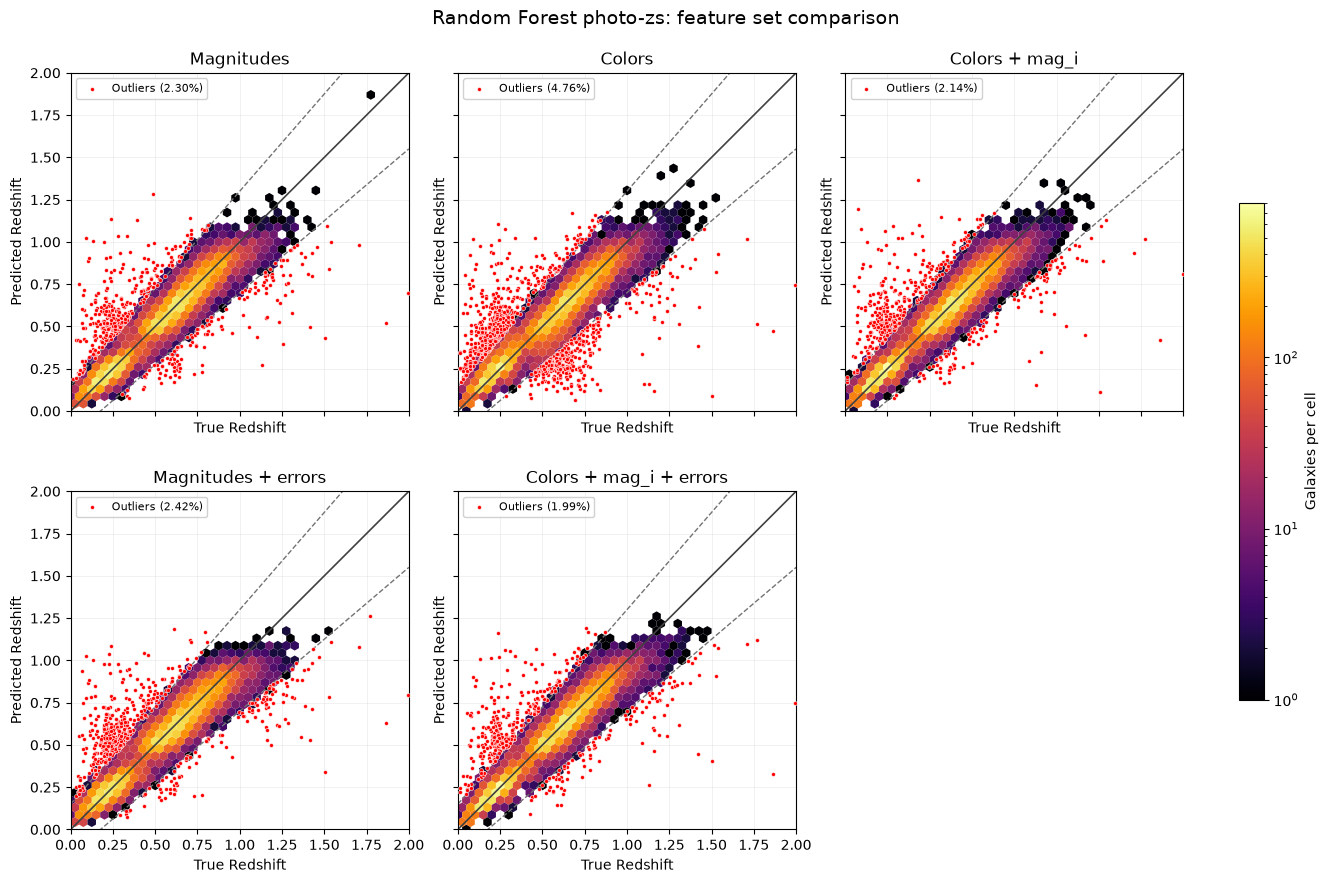

In [16]:
# Several estimation cases on ONE figure: build the grid up front, hand each
# case its own ax, and only render/save the figure once at the end
ncols = 3
nrows = int(np.ceil(len(results) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.4 * nrows),
                         sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)

mappables = []
for ax, (name, result) in zip(axes.flat, results.items()):
    _, _, hexes = create_ax_results(result['y_true'], result['y_pred'], ax=ax, title=name)
    mappables.append(hexes)

# Blank the leftover slot (5 feature sets in a 2x3 grid).
for ax in list(axes.flat)[len(results):]:
    ax.set_visible(False)

# One color scale shared by every panel. Without this each hexbin autoscales on
# its own counts and the same darkness would mean a different count per panel.
vmax = max(h.get_array().max() for h in mappables if h is not None)
for h in mappables:
    if h is not None:
        h.set_clim(1, vmax)

fig.colorbar(mappables[0], ax=axes.ravel().tolist(),
             label='Galaxies per cell', shrink=0.6)
_ = fig.suptitle('Random Forest photo-zs: feature set comparison', fontsize=14)
# fig.savefig('pz_comparison.png', dpi=200)  # constrained_layout, so no bbox_inches='tight' needed

## NÃO-PROCESSADO AINDA

#### Métricas por faixa de redshift, todos os conjuntos de atributos de uma vez

`plot_metrics` acima desenha quatro painéis para **um** modelo de cada vez. Abaixo,
`binned_metrics` separa o cálculo do desenho, e `plot_binned_metrics` sobrepõe todos
os conjuntos de atributos de `results` nos mesmos quatro painéis — assim a pergunta
"qual conjunto é melhor em $z = 0.8$?" vira uma comparação vertical dentro de um
único painel.

Três correções em relação ao cálculo original:

- $\sigma_{68}$ agora é um quantil de verdade (`np.quantile`), não `vetor_ordenado[int(0.68 \cdot N)]`;
- todas as métricas usam o resíduo normalizado $\Delta z/(1+z)$ — o código original
  misturava resíduo normalizado e não-normalizado entre as métricas;
- os intervalos dos bins são semiabertos, então galáxias exatamente na borda não são
  mais contadas em dois bins vizinhos.


In [28]:
# Colour + marker per feature set. The hue order is a validated colourblind-safe
# sequence; the marker shapes are a deliberate second encoding, so the series can
# still be told apart in greyscale, on a projector, or by a colourblind reader.
SERIES_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
SERIES_MARKERS = ['o', 's', '^', 'D', 'v']


def binned_metrics(z_spec, z_phot, bins, bin_by='phot', min_count=25):
    """Quality metrics of a photo-z estimate, computed in bins of redshift.

    Separated from the plotting on purpose: the numbers are useful on their own,
    and mixing the two is what made the original plot_metrics hard to fix.

    All metrics are built on the normalised residual dz = (z_phot - z_spec)/(1 + z_spec),
    which is the quantity the photo-z literature quotes. The original code mixed
    normalised and un-normalised residuals between metrics.

    Args:
        z_spec, z_phot: spectroscopic and photometric redshifts (same length).
        bins: bin edges, e.g. np.arange(0, 1.4, 0.1).

    Kwargs:
        bin_by: 'phot' bins on z_phot (what you can reproduce on an unlabelled
            sample), 'spec' bins on z_spec (the diagnostic view).
        min_count: bins holding fewer galaxies than this are dropped rather than
            plotted, so a bin with 3 objects does not get the same visual weight
            as one with 3000.

    Returns:
        dict of equal-length arrays: z (bin centre), n, bias, err_bias, sigma,
        sigma68, out2, out3.
    """
    z_spec = np.asarray(z_spec, dtype=float)
    z_phot = np.asarray(z_phot, dtype=float)

    dz = (z_phot - z_spec)/(1 + z_spec)
    binning_variable = z_phot if bin_by == 'phot' else z_spec

    columns = ('z', 'n', 'bias', 'err_bias', 'sigma', 'sigma68', 'out2', 'out3')
    out = {key: [] for key in columns}

    for low, high in zip(bins[:-1], bins[1:]):
        # Half-open interval: the original used <= on both edges, so galaxies
        # sitting exactly on an edge were counted in two neighbouring bins.
        in_bin = (binning_variable >= low) & (binning_variable < high)
        n = int(in_bin.sum())
        if n < min_count:
            continue

        d = dz[in_bin]
        bias = np.mean(d)
        sigma = np.std(d, ddof=1)

        out['z'].append(0.5 * (low + high))
        out['n'].append(n)
        out['bias'].append(bias)
        out['err_bias'].append(sigma/np.sqrt(n))
        out['sigma'].append(sigma)
        # A real quantile, not sorted_array[int(0.68 * len)].
        out['sigma68'].append(np.quantile(np.abs(d), 0.68))
        out['out2'].append(np.mean(np.abs(d - bias) > 2 * sigma))
        out['out3'].append(np.mean(np.abs(d - bias) > 3 * sigma))

    return {key: np.asarray(value) for key, value in out.items()}


def plot_binned_metrics(results, bins=None, bin_by='phot', min_count=25,
                        colors=None, markers=None, figsize=(11, 7)):
    """One 2x2 figure comparing every entry of `results` on four binned metrics.

    Each panel holds one metric and overlays all feature sets, so 'which feature
    set is best at z = 0.8' is a vertical comparison inside a single panel.

    Args:
        results: dict of {label: {'y_true': ..., 'y_pred': ...}}, as built by the
            training loop.

    Kwargs:
        bins: bin edges; defaults to np.arange(0, 1.4, 0.1).
        bin_by, min_count: passed through to binned_metrics.
        colors, markers: per-series styling, cycled if shorter than results.
        figsize: figure size in inches.

    Returns:
        (fig, axes)
    """
    if bins is None:
        bins = np.arange(0, 1.4, 0.1)
    colors = colors if colors is not None else SERIES_COLORS
    markers = markers if markers is not None else SERIES_MARKERS

    # (key in the stats dict, y label, reference value to mark)
    panels = [('bias',    r'$\langle \Delta z/(1+z) \rangle$', 0.0),
              ('sigma68', r'$\sigma_{68}$',                    0.12),
              ('out2',    r'out$_{2\sigma}$',                  0.10),
              ('out3',    r'out$_{3\sigma}$',                  0.10)]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True,
                             constrained_layout=True)

    for i, (name, result) in enumerate(results.items()):
        stats = binned_metrics(result['y_true'], result['y_pred'],
                               bins, bin_by=bin_by, min_count=min_count)
        style = dict(color=colors[i % len(colors)],
                     marker=markers[i % len(markers)],
                     markersize=5.5, markeredgecolor='white', markeredgewidth=0.6,
                     linewidth=1.8, label=name)

        for ax, (key, _, _) in zip(axes.flat, panels):
            if key == 'bias':
                # Only the bias panel gets error bars: it is the one place where
                # "is this consistent with zero?" is the actual question.
                ax.errorbar(stats['z'], stats['bias'], yerr=stats['err_bias'],
                            elinewidth=1, capsize=0, **style)
            else:
                ax.plot(stats['z'], stats[key], **style)

    for ax, (_, ylabel, reference) in zip(axes.flat, panels):
        ax.axhline(reference, color='0.55', linestyle='--', linewidth=1, zorder=1)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.grid(alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)  # recessive axes
        ax.tick_params(labelsize=10)

    xlabel = r'$z_\mathrm{phot}$' if bin_by == 'phot' else r'$z_\mathrm{spec}$'
    for ax in axes[-1]:
        ax.set_xlabel(xlabel, fontsize=13)
    axes.flat[0].set_xlim(bins[0], bins[-1])

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside lower center', ncols=len(labels),
               frameon=False, fontsize=10)
    fig.suptitle('Photo-z quality vs redshift, by feature set (bins with < %d '
                 'galaxies dropped)' % min_count, fontsize=13)

    return fig, axes


,MAE,sigma_NMAD,eta [%],bias
Magnitudes,0.0567,0.0381,2.3055,0.0024
Colors,0.0660,0.0406,4.8182,0.0039
Colors + mag_i,0.0530,0.0338,2.0410,0.0027
Magnitudes + errors,0.0616,0.0429,2.4598,0.0032
Colors + mag_i + errors,0.0520,0.0331,2.0278,0.0025


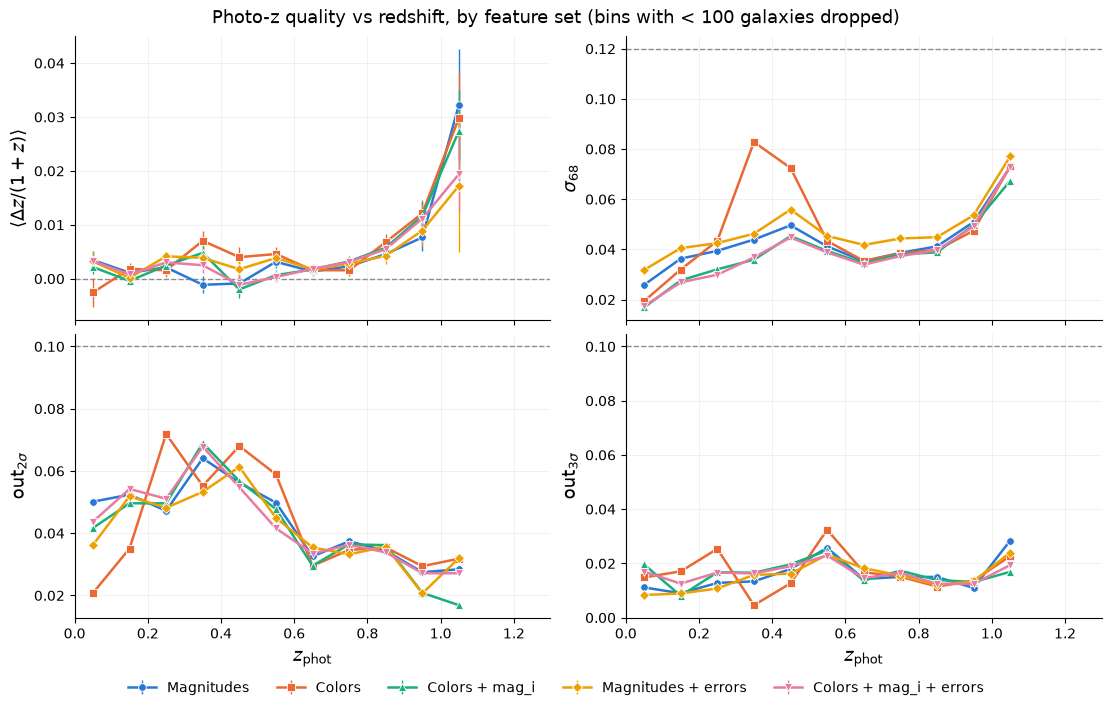

In [29]:
fig, axes = plot_binned_metrics(results, bin_by='phot', min_count=100)

# Table view of the same comparison. The legend maps colour+marker to feature set,
# but three of the five hues sit below 3:1 contrast on white, so the numbers must
# also be readable without relying on colour at all.
summary = pd.DataFrame(
    {name: {'MAE':        r['metrics']['mae'],
            'sigma_NMAD': r['metrics']['nmad'],
            'eta [%]':    100 * r['metrics']['eta'],
            'bias':       r['metrics']['bias']}
     for name, r in results.items()}).T
summary.round(4)


#### Distribuição de redshifts $N(z)$: verdade vs. reconstrução

A célula acima sobrepõe dois histogramas preenchidos com `alpha=0.5`. Onde eles se
cruzam surge uma terceira cor, que não corresponde a nenhuma das duas entradas da
legenda — e é justamente na região de sobreposição que está a informação. (A legenda
do segundo painel também está trocada: ele desenha `redshifts` e `y_pred_cross_val`,
mas rotula `y_test` e `y_pred`.)

Abaixo, o $N(z)$ espectroscópico é desenhado **uma única vez**, como referência
cinza preenchida — é a mesma amostra de teste para todos os conjuntos de atributos.
Cada predição vira um contorno em degraus por cima, e o painel inferior mostra a
razão predito/verdadeiro, que é onde o desvio fica realmente visível.


In [32]:
# Line style as a second encoding, for the same reason the panels above carry
# marker shapes: three of the five hues are low contrast on white.
SERIES_LINESTYLES = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]


def plot_nz(results, bins=None, colors=None, linestyles=None,
            ratio=True, figsize=(10, 7.5)):
    """Compare the true and the recovered redshift distribution N(z).

    The spectroscopic N(z) is drawn once, as a filled grey reference, because it
    is the same test sample for every feature set - five identical curves on top
    of each other would just be ink. Each prediction is a step outline over it.

    Two filled semi-transparent histograms (as in the cell above) are avoided on
    purpose: where they overlap, the eye sees a third colour that belongs to
    neither series and cannot be matched to the legend.

    Args:
        results: dict of {label: {'y_true': ..., 'y_pred': ...}}, as built by the
            training loop. Entries whose true N(z) differs from the first one
            (cross-validation over the full catalogue, say) get their own faint
            reference curve instead of being compared against the wrong sample.

    Kwargs:
        bins: bin edges; defaults to np.arange(0, 1.45, 0.05). Finer bins make
            the ratio panel noisier, not more informative.
        colors, linestyles: per-series styling, cycled if shorter than results.
        ratio: add the predicted/true panel underneath.
        figsize: figure size in inches.

    Returns:
        (fig, axes)
    """
    if bins is None:
        bins = np.arange(0, 1.45, 0.05)
    colors = colors if colors is not None else SERIES_COLORS
    linestyles = linestyles if linestyles is not None else SERIES_LINESTYLES

    centres = 0.5 * (bins[:-1] + bins[1:])

    if ratio:
        fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]},
                                 constrained_layout=True)
        ax_main, ax_ratio = axes
    else:
        fig, ax_main = plt.subplots(figsize=figsize, constrained_layout=True)
        axes, ax_ratio = np.array([ax_main]), None

    reference = None
    for i, (name, result) in enumerate(results.items()):
        y_true = np.asarray(result['y_true'], dtype=float)
        y_pred = np.asarray(result['y_pred'], dtype=float)
        n_true, _ = np.histogram(y_true, bins=bins)
        n_pred, _ = np.histogram(y_pred, bins=bins)

        colour = colors[i % len(colors)]
        style = linestyles[i % len(linestyles)]

        if reference is None:
            reference = n_true
            ax_main.stairs(n_true, bins, fill=True, color='0.87', zorder=1,
                           label='Spectroscopic (truth)')
            ax_main.stairs(n_true, bins, color='0.45', linewidth=1.2, zorder=2)
        elif not np.array_equal(n_true, reference):
            ax_main.stairs(n_true, bins, color=colour, linewidth=1,
                           alpha=0.45, zorder=2)

        ax_main.stairs(n_pred, bins, color=colour, linestyle=style,
                       linewidth=1.8, zorder=3, label=name)

        if ax_ratio is not None:
            # Bins with no true galaxies have no meaningful ratio - leave a gap
            # rather than drawing a spike or a zero.
            with np.errstate(divide='ignore', invalid='ignore'):
                r = np.where(n_true > 0, n_pred/np.where(n_true > 0, n_true, 1), np.nan)
            ax_ratio.plot(centres, r, color=colour, linestyle=style, linewidth=1.6)

    ax_main.set_ylabel('Galaxies per bin', fontsize=12)
    ax_main.set_xlim(bins[0], bins[-1])

    for ax in axes:
        ax.grid(alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=10)

    if ax_ratio is not None:
        ax_ratio.axhline(1.0, color='0.55', linestyle='--', linewidth=1, zorder=1)
        ax_ratio.set_ylabel('pred / true', fontsize=11)
        ax_ratio.set_xlabel(r'$z$', fontsize=13)
    else:
        ax_main.set_xlabel(r'$z$', fontsize=13)

    handles, labels = ax_main.get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside lower center',
               ncols=3, frameon=False, fontsize=10)
    fig.suptitle('Recovered vs true redshift distribution', fontsize=13)

    return fig, axes


,<z> true,<z> pred,shift
Magnitudes,0.5212,0.5202,-0.0010
Colors,0.5212,0.5205,-0.0007
Colors + mag_i,0.5212,0.5212,0.0000
Magnitudes + errors,0.5212,0.5206,-0.0006
Colors + mag_i + errors,0.5212,0.5211,-0.0002


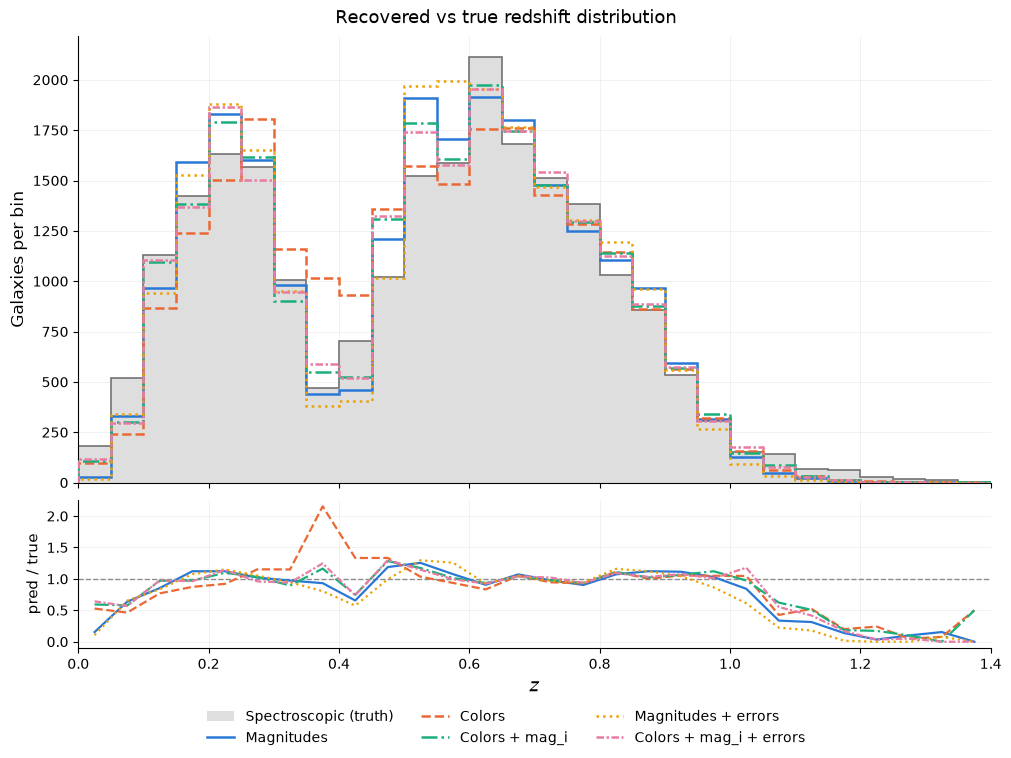

In [33]:
fig, axes = plot_nz(results)

# The number that actually matters downstream: how far the mean of the recovered
# N(z) sits from the mean of the true one.
nz_summary = pd.DataFrame(
    {name: {'<z> true':  np.mean(np.asarray(r['y_true'], dtype=float)),
            '<z> pred':  np.mean(np.asarray(r['y_pred'], dtype=float)),
            'shift':     np.mean(np.asarray(r['y_pred'], dtype=float))
                         - np.mean(np.asarray(r['y_true'], dtype=float))}
     for name, r in results.items()}).T
nz_summary.round(4)


#### $N(z)$ suavizado por KDE gaussiano com largura $\sigma_{68}(z)$

Usar **um $\sigma_{68}$ por faixa de redshift é perfeitamente possível**: basta
colocar uma gaussiana de largura $\sigma_{68}(z_i)$ centrada no photo-z de cada
galáxia e somar. Esse é o estimador de kernel adaptativo *sample-point*, e é
exatamente o que a literatura de photo-z chama de "empilhar as PDFs".

O `scipy.stats.gaussian_kde` **não** serve aqui: ele usa uma única largura de banda
para toda a amostra. Por isso a soma é escrita explicitamente em
`gaussian_kde_variable`.

Um detalhe que muda o resultado: $\sigma_{68}$ é medido sobre o resíduo
*normalizado* $\Delta z/(1+z)$, então a largura em redshift é
$\sigma_z = \sigma_{68}(z)\,(1+z)$. Sem esse fator $(1+z)$ o kernel fica cerca de
30% estreito demais em $z = 0.3$ e mais de duas vezes estreito demais em $z = 1.3$.

A versão de largura única — média de $\sigma_{68}$ em $0.1 < z < 0.9$, como pedido
no caso de não haver alternativa — é desenhada junto, para comparação.


In [34]:
def per_galaxy_sigma(z_phot, bins, stats, fallback):
    """Gaussian kernel width in redshift for every galaxy, from binned sigma_68.

    Two things are going on here.

    First, sigma_68 is measured on the *normalised* residual dz/(1 + z), so a
    galaxy at z_phot carries a width of sigma_68 * (1 + z_phot) in redshift
    itself. Skipping that factor makes the kernel ~30% too narrow at z = 0.3 and
    ~2.3x too narrow at z = 1.3.

    Second, binned_metrics drops bins with too few galaxies, so some galaxies
    fall in a bin with no measured sigma_68; those get the `fallback` value.

    Args:
        z_phot: photometric redshifts.
        bins: the bin edges that were passed to binned_metrics.
        stats: the dict returned by binned_metrics.
        fallback: sigma_68 to use for galaxies in dropped or out-of-range bins.

    Returns:
        Array of kernel widths, same length as z_phot.
    """
    centres = 0.5 * (bins[:-1] + bins[1:])

    # stats['z'] holds only the bins that survived min_count; match them back on
    # to the full list of centres.
    sigma_per_bin = np.full(centres.size, np.nan)
    rows, cols = np.where(np.isclose(centres[:, None], stats['z'][None, :]))
    sigma_per_bin[rows] = stats['sigma68'][cols]

    index = np.clip(np.digitize(z_phot, bins) - 1, 0, centres.size - 1)
    sigma68 = sigma_per_bin[index]
    sigma68 = np.where(np.isfinite(sigma68), sigma68, fallback)

    return sigma68 * (1 + z_phot)


def gaussian_kde_variable(z_grid, positions, sigmas, chunk=4000):
    """Sum of Gaussians, one per galaxy, each with its own width.

    scipy's gaussian_kde takes a single bandwidth for the whole sample, so it
    cannot express "sigma_68 per redshift range" - hence this explicit sum. It is
    the sample-point adaptive kernel estimator, and it is also exactly what
    "stacking the per-galaxy redshift PDFs" means in the photo-z literature.

    Normalised so that the integral over z equals the number of galaxies, which
    makes it directly comparable to a histogram of counts.

    Args:
        z_grid: redshifts at which to evaluate.
        positions: kernel centres (the photo-z of each galaxy).
        sigmas: kernel width for each galaxy, same length as positions.

    Kwargs:
        chunk: galaxies per block, to bound peak memory.

    Returns:
        Array of the same shape as z_grid.
    """
    total = np.zeros_like(z_grid, dtype=float)
    for start in range(0, positions.size, chunk):
        centre = positions[start:start + chunk][:, None]
        width = sigmas[start:start + chunk][:, None]
        total += (np.exp(-0.5 * ((z_grid[None, :] - centre)/width)**2)
                  / (width * np.sqrt(2 * np.pi))).sum(axis=0)
    return total


def plot_nz_kde(z_spec, z_phot, bins, z_grid, curves, title=None,
                colors=None, figsize=(10, 7.5)):
    """True N(z) against one or more smoothed reconstructions.

    Args:
        z_spec, z_phot: spectroscopic and photometric redshifts.
        bins: histogram bin edges for the true and raw photo-z distributions.
        z_grid: grid the KDE curves were evaluated on.
        curves: dict of {label: density on z_grid}, normalised to N galaxies.

    Kwargs:
        title: figure title.
        colors: one colour per curve; defaults to the shared series palette.
        figsize: figure size in inches.

    Returns:
        (fig, axes)
    """
    colors = colors if colors is not None else SERIES_COLORS
    width = bins[1] - bins[0]
    centres = 0.5 * (bins[:-1] + bins[1:])

    n_true, _ = np.histogram(z_spec, bins=bins)
    n_phot, _ = np.histogram(z_phot, bins=bins)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True,
                             gridspec_kw={'height_ratios': [3, 1]},
                             constrained_layout=True)
    ax_main, ax_ratio = axes

    ax_main.stairs(n_true, bins, fill=True, color='0.87', zorder=1,
                   label='Spectroscopic (truth)')
    ax_main.stairs(n_true, bins, color='0.45', linewidth=1.2, zorder=2)
    ax_main.stairs(n_phot, bins, color='0.45', linestyle=':', linewidth=1.2,
                   zorder=2, label='Photo-z, unsmoothed')

    for i, (label, density) in enumerate(curves.items()):
        colour = colors[i % len(colors)]
        # Densities integrate to N galaxies; multiplying by the bin width puts
        # them on the same "galaxies per bin" scale as the histograms.
        ax_main.plot(z_grid, density * width, color=colour, linewidth=2,
                     zorder=3, label=label)

        binned = np.array([np.trapezoid(density[(z_grid >= low) & (z_grid <= high)],
                                        z_grid[(z_grid >= low) & (z_grid <= high)])
                           for low, high in zip(bins[:-1], bins[1:])])
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(n_true > 0, binned/np.where(n_true > 0, n_true, 1), np.nan)
        ax_ratio.plot(centres, ratio, color=colour, linewidth=1.8)

    ax_main.set_ylabel('Galaxies per bin', fontsize=12)
    ax_main.set_xlim(bins[0], bins[-1])
    ax_main.set_ylim(bottom=0)

    ax_ratio.axhline(1.0, color='0.55', linestyle='--', linewidth=1, zorder=1)
    ax_ratio.set_ylabel('KDE / true', fontsize=11)
    ax_ratio.set_xlabel(r'$z$', fontsize=13)

    for ax in axes:
        ax.grid(alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=10)

    handles, labels = ax_main.get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside lower center', ncols=2,
               frameon=False, fontsize=10)
    if title:
        fig.suptitle(title, fontsize=13)

    return fig, axes


sigma_68 per bin (0.1 < z < 0.9): [0.0273 0.0263 0.0298 0.0302 0.031  0.045  0.0645 0.0389 0.0392 0.0383
 0.0337 0.0342 0.0377 0.0371 0.04   0.0387]
mean sigma_68 over that range   : 0.0370
per-galaxy kernel width sigma_z : 0.0123 to 0.1805 (median 0.0577)

integral of the adaptive KDE    : 22685.0  (N galaxies = 22685)
KDE mass leaking below z = 0    : 0.00 %

<z> spectroscopic               : 0.5212
<z> photo-z, unsmoothed         : 0.5211
<z> adaptive KDE                : 0.5211
<z> single-bandwidth KDE        : 0.5211


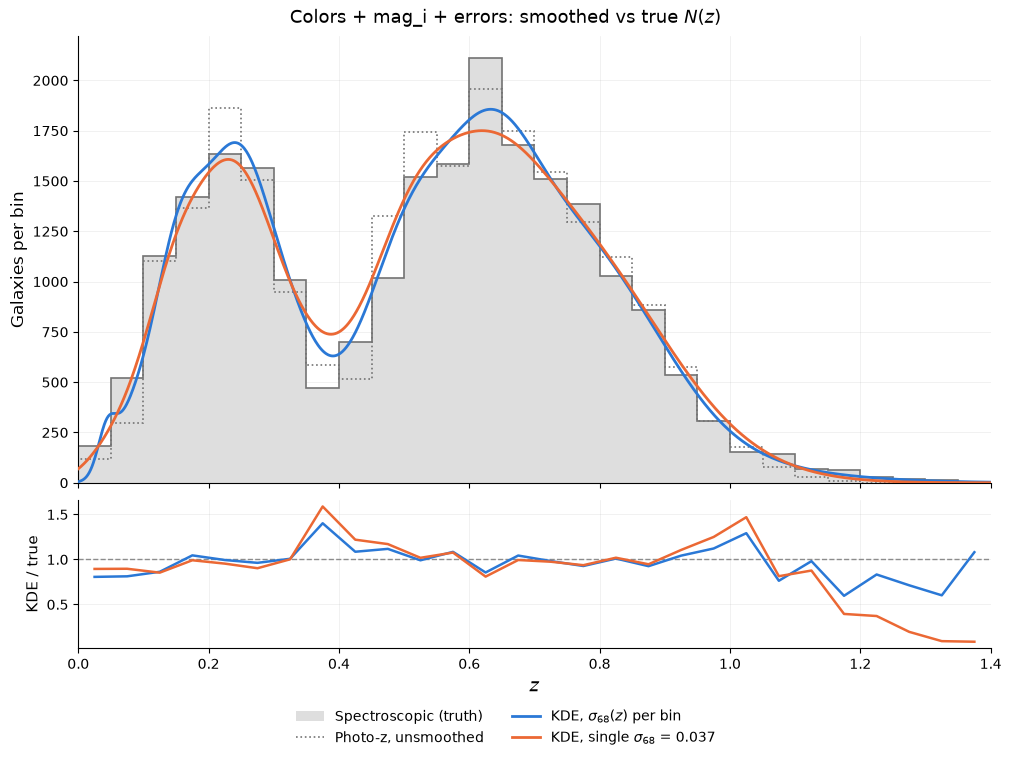

In [35]:
target = 'Colors + mag_i + errors'
z_spec = np.asarray(results[target]['y_true'], dtype=float)
z_phot = np.asarray(results[target]['y_pred'], dtype=float)

kde_bins = np.arange(0, 1.45, 0.05)
stats = binned_metrics(z_spec, z_phot, kde_bins, bin_by='phot', min_count=25)

# The single-bandwidth fallback asked for: mean sigma_68 over 0.1 < z < 0.9.
in_range = (stats['z'] > 0.1) & (stats['z'] < 0.9)
sigma68_mean = stats['sigma68'][in_range].mean()

sigma_variable = per_galaxy_sigma(z_phot, kde_bins, stats, fallback=sigma68_mean)
sigma_single = sigma68_mean * (1 + z_phot)

z_grid = np.linspace(-0.4, 1.8, 2201)
kde_variable = gaussian_kde_variable(z_grid, z_phot, sigma_variable)
kde_single = gaussian_kde_variable(z_grid, z_phot, sigma_single)

print('sigma_68 per bin (0.1 < z < 0.9): %s'
      % np.array2string(stats['sigma68'][in_range], precision=4))
print('mean sigma_68 over that range   : %.4f' % sigma68_mean)
print('per-galaxy kernel width sigma_z : %.4f to %.4f (median %.4f)'
      % (sigma_variable.min(), sigma_variable.max(), np.median(sigma_variable)))
print('\nintegral of the adaptive KDE    : %.1f  (N galaxies = %d)'
      % (np.trapezoid(kde_variable, z_grid), z_phot.size))
print('KDE mass leaking below z = 0    : %.2f %%'
      % (100 * np.trapezoid(kde_variable[z_grid < 0], z_grid[z_grid < 0])
         / z_phot.size))
print('\n<z> spectroscopic               : %.4f' % z_spec.mean())
print('<z> photo-z, unsmoothed         : %.4f' % z_phot.mean())
print('<z> adaptive KDE                : %.4f'
      % (np.trapezoid(z_grid * kde_variable, z_grid) / np.trapezoid(kde_variable, z_grid)))
print('<z> single-bandwidth KDE        : %.4f'
      % (np.trapezoid(z_grid * kde_single, z_grid) / np.trapezoid(kde_single, z_grid)))

fig, axes = plot_nz_kde(
    z_spec, z_phot, kde_bins, z_grid,
    {r'KDE, $\sigma_{68}(z)$ per bin': kde_variable,
     r'KDE, single $\sigma_{68}$ = %.3f' % sigma68_mean: kde_single},
    title='%s: smoothed vs true $N(z)$' % target)


#### $N(z)$ tomográfico: seleção em faixas de photo-z, depois suavização

Agora a amostra é dividida em cinco faixas de $z_\mathrm{phot}$ ($0.0$–$0.2$, ..., $0.8$–$1.0$) e o mesmo KDE gaussiano de largura $\sigma_{68}(z)\,(1+z)$ é aplicado **dentro de cada faixa**. A seleção é feita em $z_\mathrm{phot}$ porque, com dados reais, é o único redshift disponível na hora de montar os bins tomográficos. Os intervalos são semiabertos, então nenhuma galáxia entra em dois bins.

Cada curva é normalizada para área unitária, o que permite comparar faixas com números de galáxias muito diferentes. A tabela exportada usa exatamente a mesma grade das curvas desenhadas.

In [36]:
def tomographic_kde(z_phot, sigma, edges, z_grid):
    """Smoothed, area-normalised N(z) for each photo-z selection.

    Same kernel construction as the full-sample version - one Gaussian per
    galaxy, width sigma_68(z)*(1+z) - but applied separately to each tomographic
    slice, so each curve answers "what does the redshift distribution of the
    galaxies I selected in this photo-z interval look like once smoothed?".

    Selection is on z_phot, since that is the only redshift available when you
    build tomographic bins on real data. Intervals are half-open, so no galaxy
    is counted in two bins.

    Each column is normalised to unit area *over z_grid*, which makes bins of
    very different size directly comparable, and makes the exported CSV
    self-consistent: trapezoidal integration of any column over its own z axis
    gives 1.

    Args:
        z_phot: photometric redshifts of the whole sample.
        sigma: per-galaxy kernel width, from per_galaxy_sigma.
        edges: tomographic bin edges, e.g. [0.0, 0.2, 0.4, 0.6, 0.8, 1.0].
        z_grid: redshifts to evaluate on; also the CSV row grid.

    Returns:
        (table, meta) - table is a DataFrame indexed by z with one column per
        bin, named 'zphot_<low>_<high>_ntot_<N>'; meta carries the bin limits,
        the galaxy count and the fraction of kernel mass that landed inside
        z_grid before normalisation.
    """
    columns = {}
    rows = []

    for low, high in zip(edges[:-1], edges[1:]):
        selected = (z_phot >= low) & (z_phot < high)
        n_tot = int(selected.sum())
        if n_tot == 0:
            continue

        density = gaussian_kde_variable(z_grid, z_phot[selected], sigma[selected])

        # Before normalising: how much of the kernel mass actually fell inside
        # the exported range. Anything well below 1 means z_grid is too narrow.
        area = np.trapezoid(density, z_grid)
        captured = area/n_tot

        name = 'zphot_%.1f_%.1f_ntot_%d' % (low, high, n_tot)
        columns[name] = density/area
        rows.append({'column': name, 'z_low': low, 'z_high': high,
                     'n_tot': n_tot, 'captured': captured})

    table = pd.DataFrame(columns, index=pd.Index(z_grid, name='z'))
    return table, pd.DataFrame(rows)


def plot_tomographic_nz(table, meta, ax=None, colors=None, linestyles=None,
                        xlim=(0, 1.4), figsize=(9, 5.5)):
    """All tomographic N(z) curves on a single Axes.

    Args:
        table, meta: as returned by tomographic_kde.

    Kwargs:
        ax: draw into an existing Axes instead of making a figure.
        colors, linestyles: per-series styling, cycled if shorter.
        xlim: plotted range. The table itself extends further; the tails out
            there are numerically tiny but not exactly zero.
        figsize: figure size in inches, ignored when ax is given.

    Returns:
        (fig, ax)
    """
    colors = colors if colors is not None else SERIES_COLORS
    linestyles = linestyles if linestyles is not None else SERIES_LINESTYLES

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    else:
        fig = ax.figure

    z = table.index.to_numpy()
    for i, row in meta.reset_index(drop=True).iterrows():
        ax.plot(z, table[row['column']].to_numpy(),
                color=colors[i % len(colors)],
                linestyle=linestyles[i % len(linestyles)],
                linewidth=2,
                label=r'$%.1f < z_\mathrm{phot} < %.1f$   ($N = %d$)'
                      % (row['z_low'], row['z_high'], row['n_tot']))

    ax.set_xlim(xlim)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r'$z$', fontsize=13)
    ax.set_ylabel(r'$n(z)$   (unit area)', fontsize=12)
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=10)
    ax.legend(frameon=False, fontsize=9.5)
    ax.set_title('KDE-smoothed $N(z)$ per tomographic photo-z bin', fontsize=13)

    return fig, ax


                 column  z_low  z_high  n_tot  captured
zphot_0.2_0.4_ntot_4902    0.2     0.4   4902       1.0
zphot_0.4_0.6_ntot_5163    0.4     0.6   5163       1.0
zphot_0.6_0.8_ntot_6545    0.6     0.8   6545       1.0
zphot_0.8_1.0_ntot_2893    0.8     1.0   2893       1.0
 zphot_1.0_1.2_ntot_297    1.0     1.2    297       1.0

table shape: (2001, 5)   z from 0.000 to 2.000, step 0.0010

wrote nz_kde_tomographic.csv (2001 rows x 5 columns)


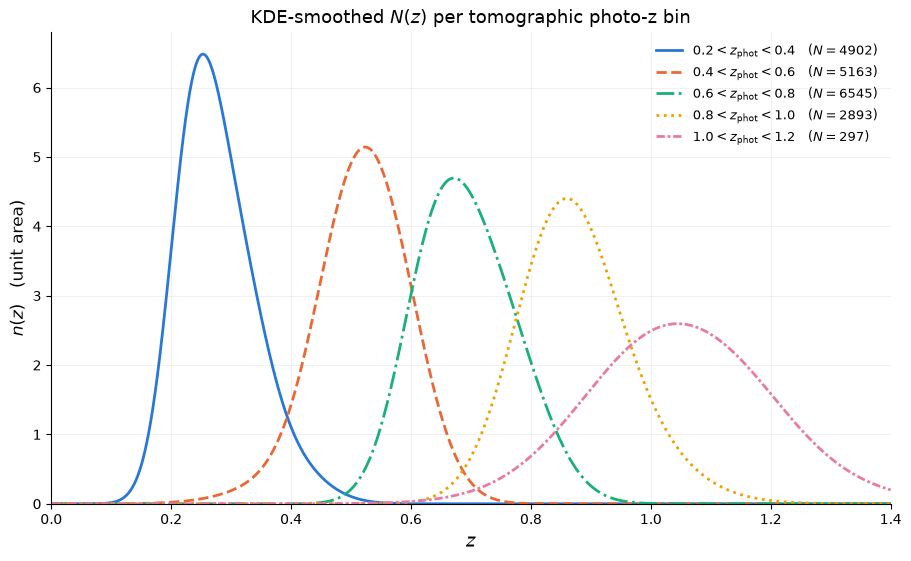

In [37]:
tomo_edges = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]

# One grid for both the plot and the CSV, so the exported numbers are exactly the
# curves that were drawn. 0 to 2 in steps of 0.001 -> 2001 rows.
export_grid = np.linspace(0, 2, 2001)

nz_table, nz_meta = tomographic_kde(z_phot, sigma_variable, tomo_edges, export_grid)

print(nz_meta.to_string(index=False))
print('\ntable shape: %s   z from %.3f to %.3f, step %.4f'
      % (nz_table.shape, nz_table.index[0], nz_table.index[-1],
         np.diff(nz_table.index)[0]))

csv_path = 'nz_kde_tomographic.csv'
nz_table.to_csv(csv_path, float_format='%.10g')
print('\nwrote %s (%d rows x %d columns)' % (csv_path, *nz_table.shape))

fig, ax = plot_tomographic_nz(nz_table, nz_meta)


# SOBRAS

#### A side note: a practical example of overfitting

In [ ]:
#y_train_pred_rf, y_train = train_and_evaluate_rf(X_train, y_train, X_train, y_train)

### 1.c) Use k-fold cross-validation

In [12]:
n_folds = 5
del rf
rf = RandomForestRegressor(n_estimators=50,
                           max_depth=30,
                           max_features=None) # FIXME: Which hyperparameters should we use? (n_estimators, max_depth, etc.)


y_pred_cross_val = cross_val_predict(rf, mags, redshifts, cv=n_folds)

Standard Deviation: 0.0615
Normalized MAD: 0.0387
Catastrophic Outlier Fraction: 2.8116
Median offset:  0.004 +/-  0.000


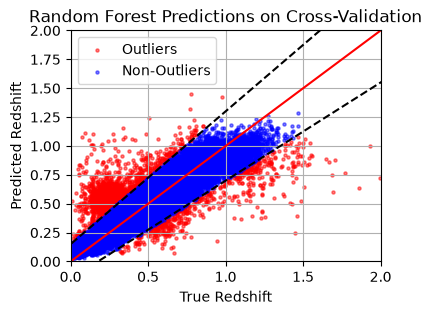

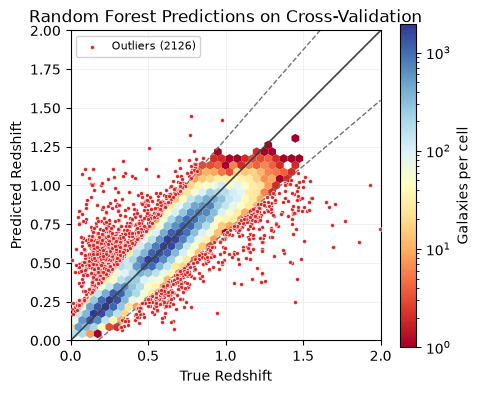

In [ ]:
# Results on cross-validation - more realistic!
_ = calculate_metrics(redshifts, y_pred_cross_val)
_ = plot_predictions(redshifts, y_pred_cross_val, "Random Forest Predictions on Cross-Validation")
_ = plot_predictions_density(redshifts, y_pred_cross_val, "Random Forest Predictions on Cross-Validation", cmap='RdYlBu')

## 2. Treino/teste de três algoritmos de aprendizado de máquina

### 2.1. Rede neural (Multi-layer perceptron)

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

mlp_test_mae = mean_absolute_error(y_test, y_pred_mlp)
print("Multi-Layer Perceptron Validation MAE:", mlp_test_mae)

### 2.2. Árvore de decisão

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_test_mae = mean_absolute_error(y_test, y_pred_dt)
print("Decision Tree Validation MAE:", dt_test_mae)

In [ ]:
# Compare plots from three results

titles = ["Multi-Layer perceptron", "Decision tree", "Random forest"]
data_sets = [y_pred_mlp, y_pred_dt, y_pred_rf]
colors = ["C0", "C1", "C2"]

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.title("Random Forest")
plt.scatter(y_test, y_pred_rf, s=2, color="C0")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
plt.xlabel(r"$z_\mathrm{true}$")
plt.ylabel(r"$z_\mathrm{phot}$")

plt.subplot(1, 3, 2)
plt.title("Decision Tree")
plt.scatter(y_test, y_pred_dt, s=2, color="C1")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
plt.xlabel(r"$z_\mathrm{true}$")
plt.ylabel(r"$z_\mathrm{phot}$")

plt.subplot(1, 3, 3)
plt.title("Multi-Layer Perceptron")
plt.scatter(y_test, y_pred_mlp, s=2, color="C2")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
_ = plt.xlabel(r"$z_\mathrm{true}$")
_ = plt.ylabel(r"$z_\mathrm{phot}$")